In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, learning_curve, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
from imblearn.over_sampling import SMOTE

In [2]:
#1. Setup Mapping (33 -> 8 Classes)
dict_8classes = {
    'DDoS-VSE': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-TCP_Flood': 'DDoS', 
    'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS', 'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    'DoS-UDP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon', 'Recon-PingSweep': 'Recon',
    'VulnerabilityScan': 'Recon', 'SqlInjection': 'Web', 'BrowserHijacking': 'Web', 'CommandInjection': 'Web',
    'Backdoor_Detection': 'Web', 'XSS': 'Web', 'Dictionary_Attack': 'Brute Force', 'Uploading_Attack': 'Brute Force',
    'DNS_Spoofing': 'Spoofing', 'MITM_ARP_Spoofing': 'Spoofing', 'BenignTraffic': 'Benign'
}

In [3]:
# 2. Loading and Filtering Tiny Classes
# Read enough rows to ensure we capture rare attack types
df = pd.read_csv('train.csv', nrows=500000) 
df['label'] = df['label'].map(dict_8classes)

# CRITICAL: Drop classes with < 10 samples to prevent "fit failed" in cross-validation
counts = df['label'].value_counts()
df = df[df['label'].isin(counts[counts >= 10].index)]

In [4]:
# 3. Stratified Sampling (50k rows)
X_raw = df.drop('label', axis=1)
y_raw = df['label']
_, X, _, y = train_test_split(X_raw, y_raw, test_size=50000, stratify=y_raw, random_state=42)

label_mapping = {val: i for i, val in enumerate(y.unique())}
y_num = y.map(label_mapping)

In [5]:
# 4. SMOTE (Applied once for Feature Importance and basic Curve)
# k_neighbors=1 handles the smallest classes without crashing
sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X, y_num)

In [6]:
# 5. Model Initialization
models = {
    "RandomForest": RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=50, learning_rate=0.1, tree_method='hist'),
    "LightGBM": LGBMClassifier(n_estimators=50, learning_rate=0.1, verbose=-1)
}

Calculating learning curve for RandomForest...

RandomForest Results:
Accuracy: 0.9789
Calculating learning curve for XGBoost...


d:\Projects\Epoch\CICIOT23\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



XGBoost Results:
Accuracy: 0.9908
Calculating learning curve for LightGBM...


d:\Projects\Epoch\CICIOT23\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



LightGBM Results:
Accuracy: 0.9998


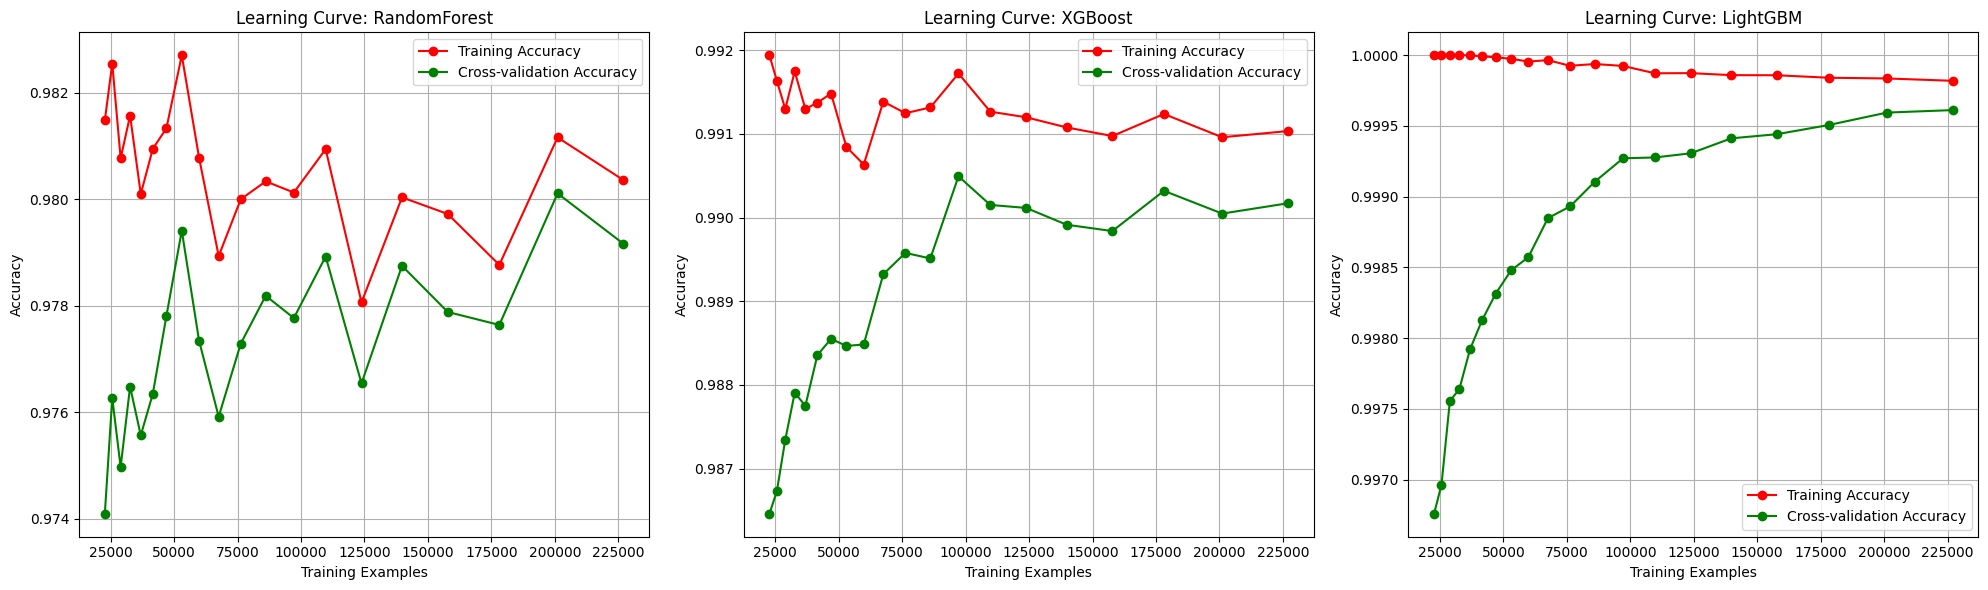

In [7]:
# 6. Plotting Learning Curves
def plot_learning_curves(models, X, y):
    plt.figure(figsize=(20, 6))
    # Use StratifiedShuffleSplit to ensure every fold is balanced and representative
    cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
    
    for i, (name, model) in enumerate(models.items()):
        print(f"Calculating learning curve for {name}...")
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=cv, n_jobs=-1, 
            train_sizes=np.geomspace(0.1, 1.0, 20), scoring='f1_macro' 
        )

        model.fit(X_res, y_res)
        y_pred = model.predict(X)
        print(f"\n{name} Results:")
        print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
        
        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        
        plt.subplot(1, 3, i+1)
        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Accuracy")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation Accuracy")
        plt.title(f"Learning Curve: {name}")
        plt.xlabel("Training Examples")
        plt.ylabel("Accuracy")
        plt.legend(loc="best")
        plt.grid()




plot_learning_curves(models, X_res, y_res)
plt.tight_layout()
plt.show()

In [9]:
# 7. Identify Features to Drop
rf = models["RandomForest"].fit(X_res, y_res)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
to_drop = importances[importances < 0.005].index.tolist()

print("\n--- RESULTS ---")
print(f"Suggested columns to drop: {to_drop}")


--- RESULTS ---
Suggested columns to drop: ['ICMP', 'IPv', 'LLC', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'DNS', 'Drate', 'cwr_flag_number', 'ece_flag_number', 'ARP', 'DHCP', 'SMTP', 'Telnet', 'SSH', 'IRC']
